# Step 4 — Exploratory data analysis

Descriptive statistics and figures for paper Sect. 4 (study-area map, Table 4, and the statistics quoted in the EDA paragraph).

- **Input:** `data/processed/flights_clean.parquet`, `wx_oracle.parquet`, `weather_hourly_utc.parquet`
- **Output:** figures in `figures/eda_*.pdf` and statistics in `results/eda_stats.json`

All analyses use the **training period (2018–2021)** unless stated otherwise, so that test data do not inform modelling choices. Weather is taken at the scheduled departure/arrival hours; this descriptive use of realized weather is distinct from the deployable features used for prediction.

### Configuration and figure style
Colours: blue = origin, orange = destination. `SUB_N` is the subsample size for Mann–Whitney and Kruskal–Wallis tests.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'README.md').exists())  # project root
warnings.filterwarnings('ignore')

DATA = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'; RESULTS.mkdir(parents=True, exist_ok=True)
FIG = ROOT / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
TRAIN_END, VAL_END = '2022-01-01', '2022-05-01'
SUB_N = 200_000
RNG = np.random.RandomState(42)
S = {}                                     # collects all statistics (saved to results/eda_stats.json)

C_ORG, C_DST, C_3 = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SEQ = LinearSegmentedColormap.from_list('seq', ['#f4f8fe', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans', 'Arial'], 'font.size': 7.5,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2, 'axes.titlesize': 8,
                     'axes.titlelocation': 'left', 'legend.frameon': False, 'pdf.fonttype': 42})

def save(fig, name):
    fig.savefig(FIG / f'{name}.pdf', bbox_inches='tight'); fig.savefig(FIG / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()

def grid_y(ax):
    ax.grid(axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)

### Load data
Flights and oracle weather, joined by `row_id`.

In [2]:
fl = pd.read_parquet(DATA / 'flights_clean.parquet',
                     columns=['row_id', 'FlightDate', 'Month', 'DayOfWeek', 'CRSDepHour', 'OriginState', 'Origin', 'Dest',
                              'Tail_Number', 'dep_utc', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15'])
WXC = ['visibility_mi', 'ceiling_ft', 'wind_mph', 'precip_in', 'dewpt_f', 'temp_f', 'humidity', 'slp',
       'has_rain', 'has_snow', 'has_fog', 'has_mist', 'has_thunder', 'has_thunder_vc', 'has_freezing', 'is_heavy', 'flight_cat_ord']
W = pd.read_parquet(DATA / 'wx_oracle.parquet', columns=['row_id'] + [f'org_{c}' for c in WXC] + [f'dst_{c}' for c in WXC])
assert (W['row_id'].values == fl['row_id'].values).all()
df = pd.concat([fl, W.drop(columns='row_id')], axis=1); del fl, W

df['part'] = np.where(df['FlightDate'] < TRAIN_END, 'train', np.where(df['FlightDate'] < VAL_END, 'val', 'test'))
tr = df[df['part'] == 'train']
print(df['part'].value_counts())

part
train    8550324
val       792335
test      638672
Name: count, dtype: int64


### Dataset overview
Sample sizes and delay statistics by split and by year.

In [3]:
for p in ['train', 'val', 'test']:
    d = df[df['part'] == p]
    S[f'n_{p}'] = int(len(d)); S[f'rate_{p}'] = float(d['ArrDel15'].mean()); S[f'mean_{p}'] = float(d['ArrDelayMinutes'].mean())
S['n_all'] = int(len(df)); S['n_airports'] = int(pd.concat([df['Origin'], df['Dest']]).nunique())
S['n_tails'] = int(df['Tail_Number'].nunique())
S['rate_all'] = float(df['ArrDel15'].mean())
S['tr_mean'] = float(tr['ArrDelayMinutes'].mean()); S['tr_median'] = float(tr['ArrDelayMinutes'].median())
S['tr_zero_share'] = float((tr['ArrDelayMinutes'] == 0).mean())
S['tr_p90'] = float(tr['ArrDelayMinutes'].quantile(0.9)); S['tr_p99'] = float(tr['ArrDelayMinutes'].quantile(0.99))
S['tr_signed_median'] = float(tr['ArrDelay'].median()); S['tr_early_share'] = float((tr['ArrDelay'] < 0).mean())
S['tr_share_over60'] = float((tr['ArrDelayMinutes'] >= 60).mean())
S['tr_top1_share_of_minutes'] = float(np.sort(tr['ArrDelayMinutes'].values)[::-1][:int(len(tr) * 0.01)].sum() / tr['ArrDelayMinutes'].sum())

yr = (df.assign(Year=df['FlightDate'].dt.year).groupby('Year')
        .agg(n=('ArrDel15', 'size'), rate=('ArrDel15', 'mean'), mean_delay=('ArrDelayMinutes', 'mean')))
S['per_year'] = yr.round(4).reset_index().to_dict('records')
print(json.dumps({k: v for k, v in S.items() if k != 'per_year'}, indent=1)); yr

{
 "n_train": 8550324,
 "rate_train": 0.17416544258594513,
 "mean_train": 12.437445640563965,
 "n_val": 792335,
 "rate_val": 0.20683297514915466,
 "mean_val": 14.9195556640625,
 "n_test": 638672,
 "rate_test": 0.23302258551120758,
 "mean_test": 16.962337493896484,
 "n_all": 9981331,
 "n_airports": 137,
 "n_tails": 6928,
 "rate_all": 0.18052472174167633,
 "tr_mean": 12.437445640563965,
 "tr_median": 0.0,
 "tr_zero_share": 0.6747531438574725,
 "tr_p90": 33.0,
 "tr_p99": 182.0,
 "tr_signed_median": -7.0,
 "tr_early_share": 0.6564206221892878,
 "tr_share_over60": 0.05726800528260684,
 "tr_top1_share_of_minutes": 0.2578140199184418
}


,n,rate,mean_delay
Year,,,
2018,1960594,0.199780,13.792318
2019,2777878,0.198187,14.557264
2020,1635896,0.099285,6.831055
2021,2175956,0.176715,12.725375
2022,1431007,0.218522,15.831268


### Delay distribution
Histogram of the signed `ArrDelay` (log scale). All early arrivals map to zero in the target `ArrDelayMinutes`, which explains its zero inflation.

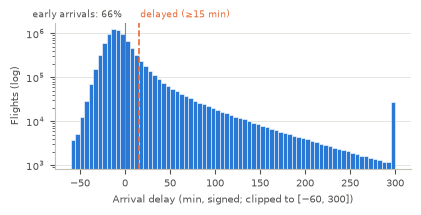

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 1.9))
x = tr['ArrDelay'].clip(-60, 300)
ax.hist(x, bins=np.arange(-60, 302, 5), color=C_ORG, edgecolor='white', linewidth=0.4)
ax.set_yscale('log'); grid_y(ax)
ax.axvline(0, color=MUTED, lw=0.8); ax.axvline(15, color=C_DST, lw=1.2, ls='--')
import matplotlib.transforms as mtr
bt = mtr.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(17, 1.02, 'delayed (≥15 min)', color=C_DST, fontsize=6.8, va='bottom', transform=bt)
ax.text(-3, 1.02, f'early arrivals: {S["tr_early_share"]:.0%}', color=INK2, fontsize=6.8, va='bottom', ha='right', transform=bt)
ax.set_xlabel('Arrival delay (min, signed; clipped to [−60, 300])'); ax.set_ylabel('Flights (log)')
save(fig, 'eda_delay_dist')

### Delay rate by departure hour and weekday
Cells with fewer than 1,000 flights are left blank.

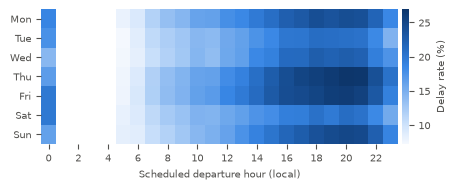

5 20 Friday Saturday


In [5]:
hm = tr.pivot_table(index='DayOfWeek', columns='CRSDepHour', values='ArrDel15', aggfunc=['mean', 'size'])
rate, cnt = hm['mean'], hm['size']
rate = rate.where(cnt >= 1000)
fig, ax = plt.subplots(figsize=(4.8, 1.75))
im = ax.imshow(rate.values * 100, aspect='auto', cmap=SEQ, interpolation='nearest')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][:rate.shape[0]])
ax.set_xticks(range(0, rate.shape[1], 2)); ax.set_xticklabels(rate.columns[::2])
ax.set_xlabel('Scheduled departure hour (local)')
for sp in ax.spines.values(): sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01); cb.set_label('Delay rate (%)', color=INK2); cb.outline.set_visible(False)
save(fig, 'eda_temporal_heatmap')
hstat = tr.groupby('CRSDepHour')['ArrDel15'].agg(['mean', 'size'])
by_hour = hstat.loc[hstat['size'] >= 10_000, 'mean']          # drop sparse hours (<10k flights)
by_dow = tr.groupby('DayOfWeek')['ArrDel15'].mean()
S['hour_min'], S['hour_min_rate'] = int(by_hour.idxmin()), float(by_hour.min())
S['hour_max'], S['hour_max_rate'] = int(by_hour.idxmax()), float(by_hour.max())
dn = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
S['dow_max'], S['dow_max_rate'] = dn[int(by_dow.idxmax())], float(by_dow.max())
S['dow_min'], S['dow_min_rate'] = dn[int(by_dow.idxmin())], float(by_dow.min())
print(S['hour_min'], S['hour_max'], S['dow_max'], S['dow_min'])

### Monthly delay rate, 2018–2022
The only figure that includes the validation and test periods (shaded), to document the COVID-19 dip and the train–test distribution shift.

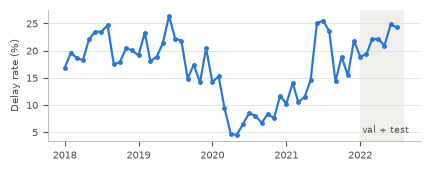

In [6]:
mo = df.groupby(df['FlightDate'].dt.to_period('M'))['ArrDel15'].mean()
t = mo.index.to_timestamp()
fig, ax = plt.subplots(figsize=(4.8, 1.7))
grid_y(ax)
ax.axvspan(pd.Timestamp(TRAIN_END), t.max() + pd.offsets.MonthEnd(1), color='#f0efec', zorder=0)
ax.text(pd.Timestamp(TRAIN_END) + pd.Timedelta(days=10), mo.min() * 100, 'val + test', fontsize=6.5, color=INK2, va='bottom')
ax.plot(t, mo.values * 100, color=C_ORG, lw=1.6, marker='o', ms=2.5)
ax.set_ylabel('Delay rate (%)')
save(fig, 'eda_monthly')
yr_rate = df.groupby(df['FlightDate'].dt.year)['ArrDel15'].mean()
S['rate_2020'] = float(yr_rate.get(2020, np.nan)); S['rate_2019'] = float(yr_rate.get(2019, np.nan))
S['month_max'] = str(mo.idxmax()); S['month_max_rate'] = float(mo.max())

### Adverse weather by state
Share of hours (2018–2021) with each condition, from the hourly weather table; colours are normalised per column.

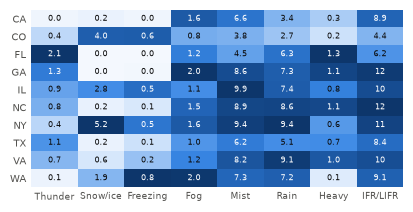

{'Thunder': ['FL', 2.0554916858673096], 'Snow/ice': ['NY', 5.154346942901611], 'Freezing': ['WA', 0.7537146806716919], 'Fog': ['GA', 2.016193151473999], 'Mist': ['IL', 9.922258377075195], 'Rain': ['NY', 9.408246994018555], 'Heavy': ['FL', 1.2557835578918457], 'IFR/LIFR': ['NC', 11.982340879343075]}


In [7]:
wh = pd.read_parquet(DATA / 'weather_hourly_utc.parquet',
                     columns=['state', 'obs_hour_utc', 'has_rain', 'has_snow', 'has_fog', 'has_mist', 'has_thunder', 'has_freezing', 'is_heavy', 'flight_cat_ord'])
wh = wh[wh['obs_hour_utc'] < TRAIN_END]
wh['ifr_or_worse'] = (wh['flight_cat_ord'] >= 2).astype(float)
cols = {'has_thunder': 'Thunder', 'has_snow': 'Snow/ice', 'has_freezing': 'Freezing', 'has_fog': 'Fog',
        'has_mist': 'Mist', 'has_rain': 'Rain', 'is_heavy': 'Heavy', 'ifr_or_worse': 'IFR/LIFR'}
sig = wh.groupby('state')[list(cols)].mean() * 100
sig = sig.rename(columns=cols)
norm = sig / sig.max()
fig, ax = plt.subplots(figsize=(4.8, 2.3))
ax.imshow(norm.values, aspect='auto', cmap=SEQ, vmin=0, vmax=1)
for i in range(sig.shape[0]):
    for j in range(sig.shape[1]):
        v = sig.values[i, j]
        ax.text(j, i, f'{v:.1f}' if v < 10 else f'{v:.0f}', ha='center', va='center', fontsize=6,
                color='white' if norm.values[i, j] > 0.6 else INK)
ax.set_xticks(range(sig.shape[1])); ax.set_xticklabels(sig.columns, fontsize=6.8)
ax.set_yticks(range(sig.shape[0])); ax.set_yticklabels(sig.index)
for sp in ax.spines.values(): sp.set_visible(False)
ax.tick_params(length=0)
save(fig, 'eda_state_signatures')
S['state_top'] = {c: [str(sig[c].idxmax()), float(sig[c].max())] for c in sig.columns}
S['hour_flag_freq'] = (wh[list(cols)].mean() * 100).rename(index=cols).round(2).to_dict()
print(S['state_top'])

### Study-area map (paper Fig. 3)
- State shading: share of hours with adverse weather (thunderstorms, snow/ice, freezing precipitation, or IFR/LIFR).
- Circles: airports with at least 1,000 training departures, sized by departures and coloured by the delay rate.

State boundaries are downloaded once as GeoJSON to `data/raw/us-states.json` (no `geopandas` required).

downloaded https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json


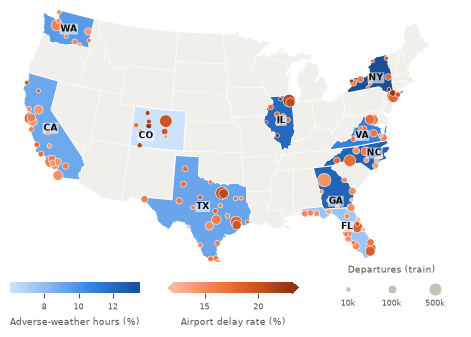

['NY', 13.560890213639865] ['CO', 6.017747765970137] ['ASE', 0.26730334758758545] ['DAB', 0.11214952915906906] rho(state adverse, state delay)= -0.13


In [8]:
import urllib.request
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
import airportsdata

GEO = ROOT / 'data' / 'raw' / 'us-states.json'; GEO.parent.mkdir(parents=True, exist_ok=True)
URLS = ['https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json',
        'https://cdn.jsdelivr.net/gh/PublicaMundi/MappingAPI@master/data/geojson/us-states.json']
if not GEO.exists():
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, GEO); print('downloaded', u); break
        except Exception as e:
            print('download failed', u, '->', e)
assert GEO.exists(), f'Download {URLS[0]} manually and save it as {GEO}'
geo = json.load(open(GEO, encoding='utf-8'))

# --- Albers equal-area projection for the contiguous US
p1, p2, p0, l0 = np.radians([29.5, 45.5, 23.0, -96.0])
nA = (np.sin(p1) + np.sin(p2)) / 2; CA = np.cos(p1) ** 2 + 2 * nA * np.sin(p1)
rho0 = np.sqrt(CA - 2 * nA * np.sin(p0)) / nA
def albers(lon, lat):
    lon, lat = np.radians(np.asarray(lon, float)), np.radians(np.asarray(lat, float))
    rho = np.sqrt(CA - 2 * nA * np.sin(lat)) / nA; th = nA * (lon - l0)
    return rho * np.sin(th), rho0 - rho * np.cos(th)

ABBR = {'California': 'CA', 'Texas': 'TX', 'Florida': 'FL', 'Illinois': 'IL', 'Georgia': 'GA', 'New York': 'NY',
        'Colorado': 'CO', 'North Carolina': 'NC', 'Virginia': 'VA', 'Washington': 'WA'}
SKIP = {'Alaska', 'Hawaii', 'Puerto Rico'}

# --- Share of adverse-weather hours by state
wh['adverse'] = ((wh['has_thunder'] == 1) | (wh['has_snow'] == 1) | (wh['has_freezing'] == 1) | (wh['flight_cat_ord'] >= 2)).astype(float)
adv = wh.groupby('state')['adverse'].mean() * 100

# --- Airports: departures and delay rate (training period)
ap_stats = tr.groupby('Origin')['ArrDel15'].agg(['mean', 'size'])
apdb = airportsdata.load('IATA')
ap_stats['lon'] = [apdb.get(c, {}).get('lon', np.nan) for c in ap_stats.index]
ap_stats['lat'] = [apdb.get(c, {}).get('lat', np.nan) for c in ap_stats.index]
ap_stats = ap_stats.dropna(subset=['lon', 'lat'])
ap_stats['x'], ap_stats['y'] = albers(ap_stats['lon'], ap_stats['lat'])

polys_study, vals_study, polys_other, label_pos = [], [], [], {}
for f in geo['features']:
    name = f['properties'].get('name')
    if name in SKIP:
        continue
    g = f['geometry']
    rings = [g['coordinates'][0]] if g['type'] == 'Polygon' else [p[0] for p in g['coordinates']]
    proj = [np.column_stack(albers(*np.array(r).T)) for r in rings]
    if name in ABBR:
        for pr in proj:
            polys_study.append(pr); vals_study.append(adv.get(ABBR[name], np.nan))
        big = max(proj, key=lambda a: np.ptp(a[:, 0]) * np.ptp(a[:, 1]))
        x_, y_ = big[:, 0], big[:, 1]                                  # polygon centroid (shoelace formula)
        cr = x_[:-1] * y_[1:] - x_[1:] * y_[:-1]; A2 = cr.sum()
        label_pos[ABBR[name]] = (((x_[:-1] + x_[1:]) * cr).sum() / (3 * A2), ((y_[:-1] + y_[1:]) * cr).sum() / (3 * A2))
    else:
        polys_other.extend(proj)

BLUE = LinearSegmentedColormap.from_list('b', ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95'])
ORNG = LinearSegmentedColormap.from_list('o', ['#f8b899', '#f28c5f', '#eb6834', '#c24f1f', '#8a3413'])
nb_ = Normalize(np.nanmin(vals_study), np.nanmax(vals_study))
big_ap = ap_stats[ap_stats['size'] >= 1000]
no_ = Normalize(big_ap['mean'].quantile(0.05) * 100, big_ap['mean'].quantile(0.95) * 100)

fig = plt.figure(figsize=(4.8, 3.15))
ax = fig.add_axes([0.0, 0.2, 1.0, 0.8])
ax.add_collection(PolyCollection(polys_other, facecolor='#f0efec', edgecolor='white', linewidth=0.4))
ax.add_collection(PolyCollection(polys_study, facecolor=BLUE(nb_(np.array(vals_study))), edgecolor='white', linewidth=0.7))
a = big_ap.sort_values('size', ascending=False)
smax = a['size'].max()
sz = lambda n: 2 + 90 * np.sqrt(n / smax)
ax.scatter(a['x'], a['y'], s=sz(a['size']), c=ORNG(no_(a['mean'] * 100)), edgecolor='white', linewidth=0.4, zorder=3)
OFF = {'CO': (-0.022, -0.012), 'GA': (0.004, -0.022), 'NC': (0.022, 0.004)}
for ab, (x, y) in label_pos.items():
    dx, dy = OFF.get(ab, (0, 0))
    ax.text(x + dx, y + dy, ab, fontsize=6.5, fontweight='bold', color=INK, ha='center', va='center', zorder=4,
            bbox=dict(boxstyle='round,pad=0.1', fc=(1, 1, 1, 0.6), ec='none'))
allxy = np.vstack(polys_study + polys_other)
ax.set_xlim(allxy[:, 0].min(), allxy[:, 0].max()); ax.set_ylim(allxy[:, 1].min(), allxy[:, 1].max())
ax.set_aspect('equal'); ax.axis('off')

cax1 = fig.add_axes([0.05, 0.1, 0.27, 0.035])
cb1 = fig.colorbar(plt.cm.ScalarMappable(nb_, BLUE), cax=cax1, orientation='horizontal')
cb1.set_label('Adverse-weather hours (%)', fontsize=6.3, color=INK2); cb1.ax.tick_params(labelsize=6); cb1.outline.set_visible(False)
cax2 = fig.add_axes([0.38, 0.1, 0.27, 0.035])
cb2 = fig.colorbar(plt.cm.ScalarMappable(no_, ORNG), cax=cax2, orientation='horizontal', extend='both')
cb2.set_label('Airport delay rate (%)', fontsize=6.3, color=INK2); cb2.ax.tick_params(labelsize=6); cb2.outline.set_visible(False)
lax = fig.add_axes([0.70, 0.03, 0.29, 0.14]); lax.axis('off')
refs = [n for n in [10_000, 100_000, 500_000] if n <= smax * 1.05] or [int(smax)]
for i, n in enumerate(refs):
    lax.scatter(i, 0.55, s=sz(n), color='#c3c2b7', edgecolor='white', linewidth=0.4)
    lax.text(i, -0.05, f'{n // 1000:,}k', ha='center', fontsize=6, color=INK2)
lax.set_xlim(-0.6, len(refs) - 0.4); lax.set_ylim(-0.4, 1.2)
lax.text((len(refs) - 1) / 2, 1.15, 'Departures (train)', ha='center', fontsize=6.3, color=INK2)
save(fig, 'eda_map')

S['adv_state'] = adv.round(2).to_dict()
S['adv_max'] = [str(adv.idxmax()), float(adv.max())]; S['adv_min'] = [str(adv.idxmin()), float(adv.min())]
big10 = ap_stats[ap_stats['size'] >= 10_000]
S['ap_n_shown'] = int(len(big_ap)); S['ap_n10k'] = int(len(big10))
S['ap_max'] = [str(big10['mean'].idxmax()), float(big10['mean'].max())]
S['ap_min'] = [str(big10['mean'].idxmin()), float(big10['mean'].min())]
st_rate = tr.groupby('OriginState')['ArrDel15'].mean()
S['state_rate_rho'] = float(stats.spearmanr(adv.reindex(st_rate.index), st_rate).correlation)
print(S['adv_max'], S['adv_min'], S['ap_max'], S['ap_min'], 'rho(state adverse, state delay)=', round(S['state_rate_rho'], 2))

### Weather conditions and delay (paper Table 4)
For each weather flag at the origin: delay rate with/without the condition (Wilson 95% CI), difference in mean delay, Cohen's *d*, Mann–Whitney *U* (subsample), and Cramér's *V*; Cohen's *d* is also computed at the destination.

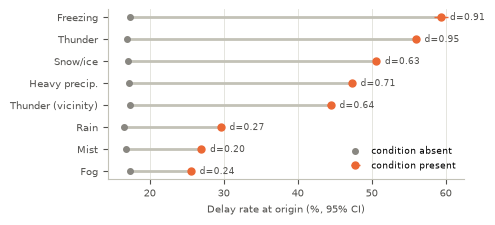

,flag,side,share_with,rate_with,rate_without,mean_with,mean_without,d,V,p_mw
0,Thunder,org,0.0109,0.5595,0.1699,53.550800,11.9833,0.9460,0.1068,0.0
1,Thunder,dst,0.0110,0.4230,0.1714,38.278999,12.1498,0.5929,0.0692,0.0
2,Freezing,org,0.0013,0.5939,0.1736,52.619499,12.3870,0.9117,0.0392,0.0
3,Freezing,dst,0.0011,0.3697,0.1739,40.308899,12.4062,0.6321,0.0173,0.0
4,Snow/ice,org,0.0087,0.5060,0.1712,39.863201,12.1955,0.6277,0.0822,0.0
5,Snow/ice,dst,0.0085,0.3144,0.1730,27.704500,12.3059,0.3489,0.0343,0.0
6,Heavy precip.,org,0.0069,0.4730,0.1721,43.517601,12.2200,0.7101,0.0659,0.0
7,Heavy precip.,dst,0.0067,0.3991,0.1727,35.105099,12.2856,0.5173,0.0485,0.0
8,Rain,org,0.0689,0.2959,0.1652,23.404100,11.6263,0.2674,0.0873,0.0
9,Rain,dst,0.0678,0.2805,0.1664,21.630199,11.7690,0.2237,0.0756,0.0


In [9]:
def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d; h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h

FLAGS = {'has_thunder': 'Thunder', 'has_freezing': 'Freezing', 'has_snow': 'Snow/ice', 'is_heavy': 'Heavy precip.',
         'has_rain': 'Rain', 'has_fog': 'Fog', 'has_thunder_vc': 'Thunder (vicinity)', 'has_mist': 'Mist'}
rows = []
for f, name in FLAGS.items():
    for side in ['org', 'dst']:
        m = tr[f'{side}_{f}'] == 1
        a, b = tr.loc[m, 'ArrDelayMinutes'], tr.loc[~m, 'ArrDelayMinutes']
        ka, kb = tr.loc[m, 'ArrDel15'].sum(), tr.loc[~m, 'ArrDel15'].sum()
        sp = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
        d = (a.mean() - b.mean()) / sp
        ss = lambda s: s.sample(min(len(s), SUB_N), random_state=0)
        p_mw = stats.mannwhitneyu(ss(a), ss(b), alternative='two-sided').pvalue if len(a) > 20 else np.nan
        ct = np.array([[ka, len(a) - ka], [kb, len(b) - kb]])
        chi2 = stats.chi2_contingency(ct, correction=False)[0]
        V = np.sqrt(chi2 / ct.sum())
        rows.append(dict(flag=name, side=side, n_with=int(len(a)), share_with=float(m.mean()),
                         rate_with=ka / len(a), rate_without=kb / len(b),
                         ci_with=wilson(ka, len(a)), ci_without=wilson(kb, len(b)),
                         mean_with=a.mean(), mean_without=b.mean(), d=d, p_mw=p_mw, V=V))
fx = pd.DataFrame(rows)
o = fx[fx['side'] == 'org'].sort_values('rate_with')
fig, ax = plt.subplots(figsize=(4.6, 2.2))
y = np.arange(len(o))
ax.hlines(y, o['rate_without'] * 100, o['rate_with'] * 100, color='#c3c2b7', lw=2)
ax.errorbar(o['rate_with'] * 100, y, xerr=np.abs(np.vstack(o['ci_with']).T * 100 - (o['rate_with'].values * 100)),
            fmt='o', color=C_DST, ms=5, capsize=0, lw=1, label='condition present')
ax.plot(o['rate_without'] * 100, y, 'o', color=MUTED, ms=4, label='condition absent')
for yi, (_, r) in zip(y, o.iterrows()):
    ax.text(r['rate_with'] * 100 + 1.2, yi, f"d={r['d']:.2f}", va='center', fontsize=6.3, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(o['flag']); ax.set_xlabel('Delay rate at origin (%, 95% CI)')
ax.grid(axis='x', color=GRID, lw=0.6); ax.set_axisbelow(True)
ax.legend(loc='lower right', fontsize=6.5)
save(fig, 'eda_weather_flags')
S['flags'] = fx.drop(columns=['ci_with', 'ci_without']).round(4).to_dict('records')
fx[['flag', 'side', 'share_with', 'rate_with', 'rate_without', 'mean_with', 'mean_without', 'd', 'V', 'p_mw']].round(4)

### FAA flight category
Delay rate by flight category at origin and destination; Kruskal–Wallis test with effect size ε².

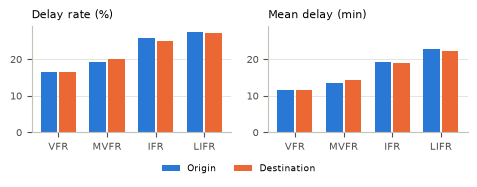

{'H': 2567.540771484375, 'p': 0.0, 'eps2': 0.006411415990442038, 'n_sub': 400000} {'H': 2265.91357421875, 'p': 0.0, 'eps2': 0.00565734039992094, 'n_sub': 400000}


In [10]:
CAT = ['VFR', 'MVFR', 'IFR', 'LIFR']
fc = {}
for side in ['org', 'dst']:
    g = tr[tr[f'{side}_flight_cat_ord'] >= 0].groupby(f'{side}_flight_cat_ord')
    fc[side] = pd.DataFrame({'rate': g['ArrDel15'].mean(), 'n': g.size(), 'mean': g['ArrDelayMinutes'].mean(),
                             'k': g['ArrDel15'].sum()}).reindex(range(4))
    valid = tr[tr[f'{side}_flight_cat_ord'] >= 0]
    sub = valid.sample(min(SUB_N * 2, len(valid)), random_state=0)
    groups = [sub.loc[sub[f'{side}_flight_cat_ord'] == k, 'ArrDelayMinutes'] for k in range(4)]
    groups = [x for x in groups if len(x) > 1]
    Hs, p = stats.kruskal(*groups)
    n = sum(len(x) for x in groups); k = len(groups)
    S[f'kw_{side}'] = dict(H=float(Hs), p=float(p), eps2=float((Hs - k + 1) / (n - k)), n_sub=int(n))
    S[f'cat_{side}'] = fc[side].round(4).reset_index().to_dict('records')

fig, axs = plt.subplots(1, 2, figsize=(4.8, 1.8), sharey=True)
w = 0.38
for ax, met, lab in zip(axs, ['rate', 'mean'], ['Delay rate (%)', 'Mean delay (min)']):
    grid_y(ax)
    for i, (side, col) in enumerate([('org', C_ORG), ('dst', C_DST)]):
        vals = fc[side][met].values * (100 if met == 'rate' else 1)
        bars = ax.bar(np.arange(4) + (i - 0.5) * w, vals, width=w - 0.04, color=col, label={'org': 'Origin', 'dst': 'Destination'}[side])
    ax.set_xticks(range(4)); ax.set_xticklabels(CAT); ax.set_title(lab)
axs[1].yaxis.set_tick_params(labelleft=True)
h_, l_ = axs[0].get_legend_handles_labels()
fig.legend(h_, l_, loc='lower center', ncol=2, fontsize=6.5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(w_pad=1.5, rect=(0, 0.08, 1, 1))
save(fig, 'eda_flight_category')
print(S['kw_org'], S['kw_dst'])

### Delay rate by binned continuous weather variables
Operational (FAA) thresholds for visibility and ceiling; equal-width bins for wind and precipitation.

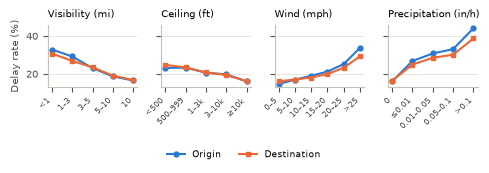

In [11]:
BINS = {
    'visibility_mi': ([-0.1, 1, 3, 5, 9.99, 10.1], ['<1', '1–3', '3–5', '5–10', '10'], 'Visibility (mi)'),
    'ceiling_ft': ([-1, 499, 999, 3000, 9999, 25001], ['<500', '500–999', '1–3k', '3–10k', '≥10k'], 'Ceiling (ft)'),
    'wind_mph': ([-0.1, 5, 10, 15, 20, 25, 101], ['0–5', '5–10', '10–15', '15–20', '20–25', '>25'], 'Wind (mph)'),
    'precip_in': ([-0.001, 0.0001, 0.01, 0.05, 0.1, 5.1], ['0', '≤0.01', '0.01–0.05', '0.05–0.1', '>0.1'], 'Precipitation (in/h)'),
}
fig, axs = plt.subplots(1, 4, figsize=(4.9, 1.6), sharey=True)
S['bins'] = {}
for ax, (v, (edges, labels, title)) in zip(axs, BINS.items()):
    grid_y(ax)
    for side, col, mk in [('org', C_ORG, 'o'), ('dst', C_DST, 's')]:
        b = pd.cut(tr[f'{side}_{v}'], edges, labels=labels)
        r = tr.groupby(b, observed=False)['ArrDel15'].agg(['mean', 'size'])
        r.loc[r['size'] < 500, 'mean'] = np.nan
        ax.plot(range(len(labels)), r['mean'] * 100, color=col, marker=mk, ms=3.5, lw=1.5,
                label={'org': 'Origin', 'dst': 'Destination'}[side])
        S['bins'][f'{side}_{v}'] = {str(k): [float(m), int(n)] for k, (m, n) in r.iterrows()}
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)
    ax.set_title(title, fontsize=7)
axs[0].set_ylabel('Delay rate (%)')
h_, l_ = axs[0].get_legend_handles_labels()
fig.legend(h_, l_, loc='lower center', ncol=2, fontsize=6.5, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(w_pad=0.6, rect=(0, 0.1, 1, 1))
save(fig, 'eda_weather_bins')

### Spearman rank correlations
Between individual weather variables and delay, on a 1M-flight training subsample.

In [12]:
sub = tr.sample(min(1_000_000, len(tr)), random_state=0)
cont = ['visibility_mi', 'ceiling_ft', 'wind_mph', 'precip_in', 'dewpt_f', 'temp_f', 'humidity', 'slp']
sp_rows = []
for v in cont:
    for side in ['org', 'dst']:
        x = sub[f'{side}_{v}']; ok = x.notna()
        rho = stats.spearmanr(x[ok], sub.loc[ok, 'ArrDelayMinutes']).correlation
        sp_rows.append(dict(var=v, side=side, rho=rho))
spt = pd.DataFrame(sp_rows).pivot(index='var', columns='side', values='rho').reindex(cont)
S['spearman'] = spt.round(4).reset_index().to_dict('records')
S['spearman_max_abs'] = float(spt.abs().max().max())
spt.round(3)

side,dst,org
var,,
visibility_mi,-0.065,-0.073
ceiling_ft,-0.077,-0.071
wind_mph,0.043,0.066
precip_in,0.104,0.118
dewpt_f,0.048,0.035
temp_f,-0.004,0.017
humidity,0.100,0.050
slp,-0.065,-0.074


### Delay propagation
Delay rate by the arrival delay of the previous leg of the same aircraft (consecutive same-day legs within the study area). Descriptive only; the model features in `06_propagation.ipynb` search the complete BTS file within 12 h.

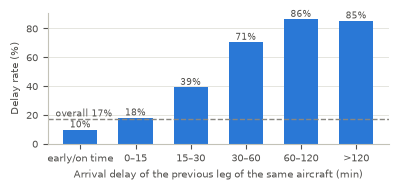

,mean,size
prev_delay,,
early/on time,0.098027,3219720
0–15,0.181419,735649
15–30,0.392709,270391
30–60,0.705717,211473
60–120,0.864846,133477
>120,0.854141,74819


In [13]:
q = tr[['Tail_Number', 'dep_utc', 'Origin', 'Dest', 'ArrDelay', 'ArrDel15', 'FlightDate']].sort_values(['Tail_Number', 'dep_utc'])
prev = q.shift(1)
ok = (q['Tail_Number'] == prev['Tail_Number']) & (q['Origin'] == prev['Dest']) & (q['FlightDate'] == prev['FlightDate'])
q = q[ok].assign(prev_delay=prev.loc[ok, 'ArrDelay'])
PB = [-1e9, 0, 15, 30, 60, 120, 1e9]; PL = ['early/on time', '0–15', '15–30', '30–60', '60–120', '>120']
r = q.groupby(pd.cut(q['prev_delay'], PB, labels=PL), observed=False)['ArrDel15'].agg(['mean', 'size'])
fig, ax = plt.subplots(figsize=(4.4, 1.7))
grid_y(ax)
ax.bar(range(len(PL)), r['mean'] * 100, color=C_ORG, width=0.62)
ax.axhline(S['rate_train'] * 100, color=MUTED, ls='--', lw=1)
ax.text(-0.45, S['rate_train'] * 100 + 1.5, f"overall {S['rate_train']:.0%}", ha='left', fontsize=6.5, color=INK2)
for i, v in enumerate(r['mean'] * 100):
    ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=6.3, color=INK2)
ax.set_xticks(range(len(PL))); ax.set_xticklabels(PL)
ax.set_xlabel('Arrival delay of the previous leg of the same aircraft (min)'); ax.set_ylabel('Delay rate (%)')
save(fig, 'eda_propagation')
S['prop_share_with_prev'] = float(len(q) / len(tr))
S['prop_rate'] = {str(k): [float(m), int(n)] for k, (m, n) in r.iterrows()}
S['prop_spearman'] = float(stats.spearmanr(q['prev_delay'].sample(min(len(q), 1_000_000), random_state=0),
                                          q['ArrDelay'].sample(min(len(q), 1_000_000), random_state=0)).correlation)
r

### Export statistics
Saves all statistics computed above to `results/eda_stats.json`.

In [14]:
json.dump(S, open(RESULTS / 'eda_stats.json', 'w'), indent=1, default=float)
print('saved', RESULTS / 'eda_stats.json')
print(f"n_train = {S['n_train']:,} | n_val = {S['n_val']:,} | n_test = {S['n_test']:,}")


saved c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\results\eda_stats.json
n_train = 8,550,324 | n_val = 792,335 | n_test = 638,672
